<a href="https://colab.research.google.com/github/SAM126599/Data-Analysis-of-Hotel-Booking/blob/main/SuperMarket_Project2nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
# Load DataSet
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ALL IZZZ WELLL..../Projects.../SuperMarket_Data.csv')
df.head()



Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Invoice_ID,Transaction_Date,City,Payment_Method,Product,Quantity,Unit_Price,Total_Price,Discount_%,Discount_Amount,Final_Price
0,INV001,2025-02-06,Hyderabad,Cash,Rice,2,70,140,5,7.00,133.00
1,INV001,2025-02-06,Hyderabad,Cash,Eggs,2,60,120,5,6.00,114.00
2,INV001,2025-02-06,Hyderabad,Cash,Chicken,2,120,240,15,36.00,204.00
3,INV002,2025-05-28,Hyderabad,Debit Card,Butter,3,55,165,15,24.75,140.25
4,INV002,2025-05-28,Hyderabad,Debit Card,Yogurt,1,45,45,15,6.75,38.25


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
print("Total Revenue (Before Discount):", df["Total_Price"].sum())
print("Total Revenue (After Discount):", df["Final_Price"].sum())
print("Total Discount Given:", df["Discount_Amount"].sum())


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total Revenue (Before Discount): 54989
Total Revenue (After Discount): 49336.95
Total Discount Given: 5652.05


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [26]:
transactions = df.groupby('Invoice_ID')['Product'].apply(list).values.tolist()          # Group products by Invoice_ID

te = TransactionEncoder()              # Convert to one-hot encoding format
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Apples,Bananas,Bread,Butter,Cereal,Cheese,Chicken,Eggs,Milk,Onions,Pasta,Potatoes,Rice,Tomatoes,Yogurt
0,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False
1,False,False,True,True,True,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,True,True,False,False,True,False,True,False,True,False
3,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
frequent_itemsets = apriori(
    basket,
    min_support=0.05,   # 5% minimum support
    use_colnames=True
)

frequent_itemsets.sort_values(by="support", ascending=False).head(10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
1,0.269504,(Bananas)
3,0.262411,(Butter)
10,0.255319,(Pasta)
4,0.255319,(Cereal)
7,0.248227,(Eggs)
9,0.248227,(Onions)
11,0.241135,(Potatoes)
8,0.241135,(Milk)
5,0.234043,(Cheese)
13,0.226950,(Tomatoes)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [28]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Ensure df is loaded (assuming file_path is defined elsewhere or directly in cell)
file_path = "/content/drive/MyDrive/ALL IZZZ WELLL..../Projects.../SuperMarket_Data.csv"
df = pd.read_csv(file_path)

# Re-create transactions, basket, and frequent_itemsets for this cell's scope
transactions = df.groupby('Invoice_ID')['Product'].apply(list).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(
    basket,
    min_support=0.01,   # Lowered minimum support to 1%
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1   # Lowered minimum confidence to 10%
)

rules.sort_values(by="lift", ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
870,"(Pasta, Yogurt)","(Butter, Eggs)",0.056738,0.035461,0.014184,0.250000,7.050000,1.0,0.012172,1.286052,0.909774,0.181818,0.222426,0.325000
871,"(Butter, Eggs)","(Pasta, Yogurt)",0.035461,0.056738,0.014184,0.400000,7.050000,1.0,0.012172,1.572104,0.889706,0.181818,0.363910,0.325000
832,"(Potatoes, Eggs)","(Bananas, Rice)",0.035461,0.056738,0.014184,0.400000,7.050000,1.0,0.012172,1.572104,0.889706,0.181818,0.363910,0.325000
823,"(Potatoes, Eggs)","(Pasta, Bananas)",0.035461,0.056738,0.014184,0.400000,7.050000,1.0,0.012172,1.572104,0.889706,0.181818,0.363910,0.325000
818,"(Pasta, Bananas)","(Potatoes, Eggs)",0.056738,0.035461,0.014184,0.250000,7.050000,1.0,0.012172,1.286052,0.909774,0.181818,0.222426,0.325000
829,"(Bananas, Rice)","(Potatoes, Eggs)",0.056738,0.035461,0.014184,0.250000,7.050000,1.0,0.012172,1.286052,0.909774,0.181818,0.222426,0.325000
780,"(Yogurt, Apples)","(Tomatoes, Cereal)",0.049645,0.042553,0.014184,0.285714,6.714286,1.0,0.012072,1.340426,0.895522,0.181818,0.253968,0.309524
782,"(Tomatoes, Apples)","(Yogurt, Cereal)",0.049645,0.042553,0.014184,0.285714,6.714286,1.0,0.012072,1.340426,0.895522,0.181818,0.253968,0.309524
919,"(Pasta, Rice)","(Potatoes, Cheese)",0.049645,0.042553,0.014184,0.285714,6.714286,1.0,0.012072,1.340426,0.895522,0.181818,0.253968,0.309524
749,"(Bananas, Butter)","(Cheese, Apples)",0.049645,0.042553,0.014184,0.285714,6.714286,1.0,0.012072,1.340426,0.895522,0.181818,0.253968,0.309524


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
strong_rules = rules[
    (rules['lift'] > 1.2) &
    (rules['confidence'] > 0.6)
]

strong_rules.sort_values(by="lift", ascending=False)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
762,"(Onions, Apples)","(Bananas, Eggs)",0.021277,0.113475,0.014184,0.666667,5.875000,1.0,0.011770,2.659574,0.847826,0.117647,0.624000,0.395833
864,"(Pasta, Butter, Eggs)",(Yogurt),0.014184,0.205674,0.014184,1.000000,4.862069,1.0,0.011267,inf,0.805755,0.068966,1.000000,0.534483
915,"(Pasta, Potatoes, Cheese)",(Rice),0.014184,0.205674,0.014184,1.000000,4.862069,1.0,0.011267,inf,0.805755,0.068966,1.000000,0.534483
744,"(Bananas, Cheese, Butter)",(Apples),0.014184,0.219858,0.014184,1.000000,4.548387,1.0,0.011066,inf,0.791367,0.064516,1.000000,0.532258
776,"(Yogurt, Cereal, Apples)",(Tomatoes),0.014184,0.226950,0.014184,1.000000,4.406250,1.0,0.010965,inf,0.784173,0.062500,1.000000,0.531250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,"(Onions, Apples)",(Bananas),0.021277,0.269504,0.014184,0.666667,2.473684,1.0,0.008450,2.191489,0.608696,0.051282,0.543689,0.359649
816,"(Pasta, Potatoes, Eggs)",(Bananas),0.021277,0.269504,0.014184,0.666667,2.473684,1.0,0.008450,2.191489,0.608696,0.051282,0.543689,0.359649
797,"(Cheese, Eggs, Cereal)",(Bananas),0.021277,0.269504,0.014184,0.666667,2.473684,1.0,0.008450,2.191489,0.608696,0.051282,0.543689,0.359649
747,"(Butter, Cheese, Apples)",(Bananas),0.021277,0.269504,0.014184,0.666667,2.473684,1.0,0.008450,2.191489,0.608696,0.051282,0.543689,0.359649


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
rules.to_csv("all_association_rules.csv", index=False)
strong_rules.to_csv("strong_association_rules.csv", index=False)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [31]:
discount_transactions = df[df["Discount_%"] > 0] \
                        .groupby("Invoice_ID")["Product"] \
                        .apply(list).values.tolist()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

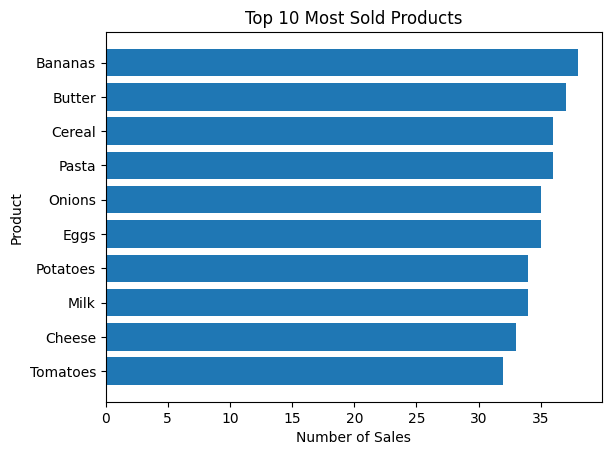

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [32]:
import matplotlib.pyplot as plt

top_products = df["Product"].value_counts().head(10)

plt.figure()
plt.barh(top_products.index, top_products.values)

plt.title("Top 10 Most Sold Products")
plt.xlabel("Number of Sales")
plt.ylabel("Product")

plt.gca().invert_yaxis()   # Highest value at top
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

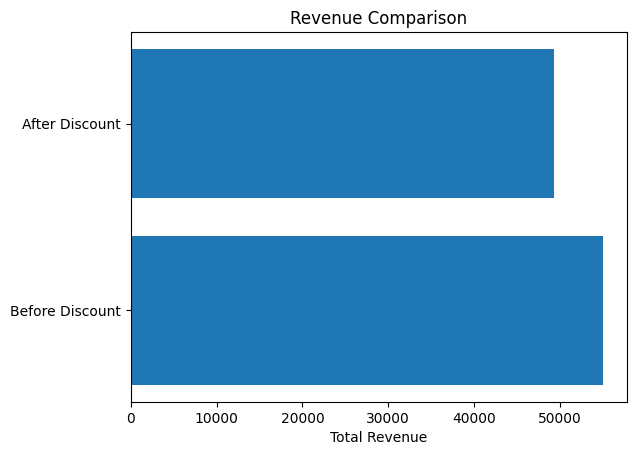

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

file_path = "/content/drive/MyDrive/SuperMarket_Data.csv"
df = pd.read_csv(file_path)

total_before = df["Total_Price"].sum()
total_after = df["Final_Price"].sum()

plt.figure()
plt.barh(["Before Discount", "After Discount"],
         [total_before, total_after])

plt.title("Revenue Comparison")
plt.xlabel("Total Revenue")
plt.ylabel("")

plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

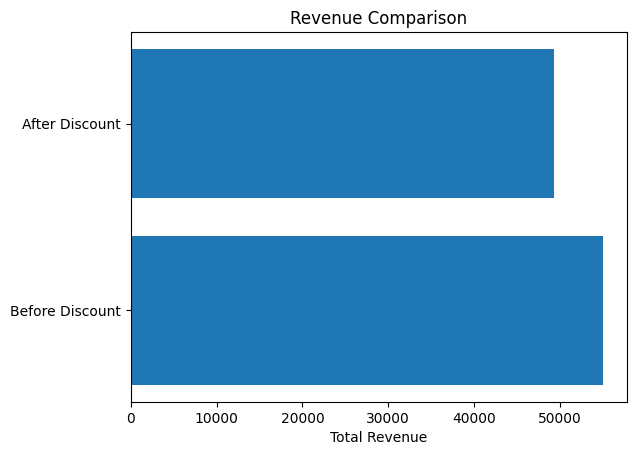

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

file_path = "/content/drive/MyDrive/ALL IZZZ WELLL..../Projects.../SuperMarket_Data.csv"
df = pd.read_csv(file_path)

total_before = df["Total_Price"].sum()
total_after = df["Final_Price"].sum()

plt.figure()
plt.barh(["Before Discount", "After Discount"],
         [total_before, total_after])

plt.title("Revenue Comparison")
plt.xlabel("Total Revenue")
plt.ylabel("")

plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

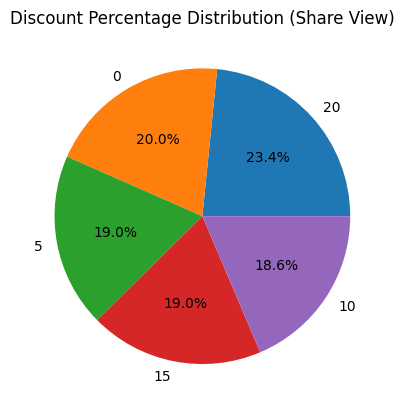

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [35]:
import matplotlib.pyplot as plt

discount_counts = df["Discount_%"].value_counts()

plt.figure()
plt.pie(discount_counts.values,
        labels=discount_counts.index,
        autopct='%1.1f%%')

plt.title("Discount Percentage Distribution (Share View)")
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

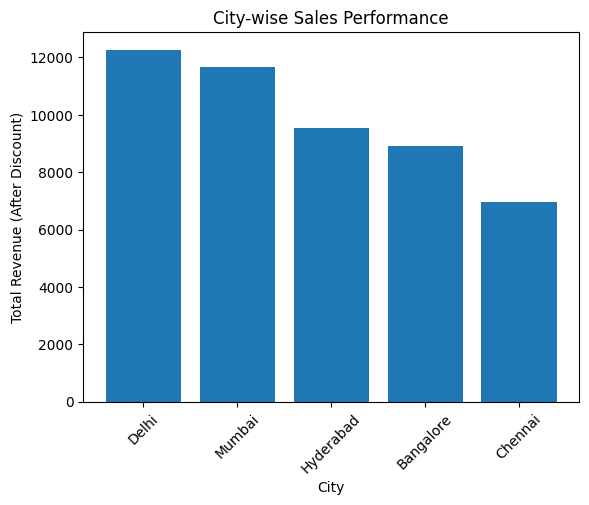

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [36]:
# City-wise Total Sales (After Discount)

city_sales = df.groupby("City")["Final_Price"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(city_sales.index, city_sales.values)

plt.title("City-wise Sales Performance")
plt.xlabel("City")
plt.ylabel("Total Revenue (After Discount)")
plt.xticks(rotation=45)

plt.show()

In [37]:
discount_transactions = df[df["Discount_%"] > 0] \
                        .groupby("Invoice_ID")["Product"] \
                        .apply(list).values.tolist()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [38]:
print(discount_transactions)
print(discount_transactions[:5])



[['Rice', 'Eggs', 'Chicken'], ['Butter', 'Yogurt', 'Bread', 'Cereal'], ['Potatoes', 'Onions', 'Cheese', 'Chicken'], ['Bananas'], ['Bananas', 'Eggs', 'Pasta'], ['Chicken', 'Rice'], ['Cheese', 'Cereal'], ['Bread', 'Chicken', 'Bananas'], ['Potatoes', 'Apples'], ['Potatoes', 'Milk', 'Apples'], ['Onions', 'Pasta'], ['Milk', 'Pasta'], ['Pasta', 'Onions', 'Potatoes', 'Eggs'], ['Butter', 'Apples', 'Cheese'], ['Tomatoes'], ['Bananas', 'Chicken', 'Milk'], ['Potatoes'], ['Rice', 'Eggs'], ['Rice', 'Potatoes', 'Onions'], ['Yogurt', 'Bread'], ['Rice', 'Eggs', 'Tomatoes', 'Bananas', 'Potatoes'], ['Eggs', 'Onions', 'Bananas'], ['Yogurt'], ['Milk', 'Bread', 'Yogurt'], ['Cheese', 'Tomatoes', 'Butter', 'Bread', 'Chicken'], ['Chicken', 'Butter', 'Yogurt'], ['Chicken', 'Pasta'], ['Eggs', 'Bananas'], ['Butter', 'Potatoes', 'Apples'], ['Bread', 'Butter', 'Chicken'], ['Potatoes'], ['Apples', 'Bananas', 'Eggs', 'Onions'], ['Bananas', 'Eggs', 'Butter'], ['Milk', 'Cereal', 'Rice'], ['Milk', 'Bananas', 'Cereal', 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [39]:
print("Total Discounted Transactions:", len(discount_transactions))


Total Discounted Transactions: 139


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [40]:
discount_df = df[df["Discount_%"] > 0]
print(discount_df.head())


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Invoice_ID Transaction_Date       City Payment_Method  Product  Quantity  \
0     INV001       2025-02-06  Hyderabad           Cash     Rice         2   
1     INV001       2025-02-06  Hyderabad           Cash     Eggs         2   
2     INV001       2025-02-06  Hyderabad           Cash  Chicken         2   
3     INV002       2025-05-28  Hyderabad     Debit Card   Butter         3   
4     INV002       2025-05-28  Hyderabad     Debit Card   Yogurt         1   

   Unit_Price  Total_Price  Discount_%  Discount_Amount  Final_Price  
0          70          140           5             7.00       133.00  
1          60          120           5             6.00       114.00  
2         120          240          15            36.00       204.00  
3          55          165          15            24.75       140.25  
4          45           45          15             6.75        38.25  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [41]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

file_path = "/content/drive/MyDrive/ALL IZZZ WELLL..../Projects.../SuperMarket_Data.csv" # Ensure correct file path
df = pd.read_csv(file_path)

# Re-calculate revenue details
total_before = df["Total_Price"].sum()
total_after = df["Final_Price"].sum()

# Re-calculate discounted transactions
discount_transactions = df[df["Discount_%"] > 0] \
                        .groupby("Invoice_ID")["Product"] \
                        .apply(list).values.tolist()

# Re-calculate top products
top_products = df["Product"].value_counts().head(10)

# Re-calculate frequent itemsets and association rules
transactions = df.groupby('Invoice_ID')['Product'].apply(list).values.tolist()
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)
frequent_itemsets = apriori(
    basket,
    min_support=0.01,                            # Lowered minimum support to 1%
    use_colnames=True
)
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1                             # Lowered minimum confidence to 10%
)

# Re-calculate discount percentage distribution
discount_counts = df["Discount_%"].value_counts()

# Re-calculate city-wise sales
city_sales = df.groupby("City")["Final_Price"].sum().sort_values(ascending=False)

output_content = []

output_content.append("Market Basket Analysis Report\n")
output_content.append("===========================================\n")

output_content.append("1. Revenue Details:\n")
output_content.append(f"Total Revenue (Before Discount): {total_before:.2f}\n")
output_content.append(f"Total Revenue (After Discount): {total_after:.2f}\n")
output_content.append(f"Total Discount Given: {df['Discount_Amount'].sum():.2f}\n")
output_content.append(f"Total Discounted Transactions: {len(discount_transactions)}\n\n")

output_content.append("2. Top 10 Most Sold Products:\n")
output_content.append(top_products.to_string() + "\n\n")

output_content.append(frequent_itemsets.sort_values(by='support', ascending=False).head(10).to_string(index=False) + "\n\n")

output_content.append("4. Top 10 Association Rules (by Lift):\n")
if not rules.empty:
    output_content.append(rules.sort_values(by="lift", ascending=False).head(10).to_string(index=False) + "\n\n")
else:
    output_content.append("No association rules found with current thresholds.\n\n")

output_content.append("5. Discount Percentage Distribution:\n")
output_content.append(discount_counts.to_string() + "\n\n")

output_content.append("6. City-wise Sales Performance (After Discount):\n")
output_content.append(city_sales.to_string() + "\n\n")
output_file_name = "Market_Basket_Analysis.csv"
with open(output_file_name, "w") as f:
    f.writelines(output_content)

print(f"All analysis outputs saved to '{output_file_name}'")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

All analysis outputs saved to 'Market_Basket_Analysis.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [42]:
!pip install reportlab pandas
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch

# Create PDF
pdf_file_name = "Market_Basket_Analysis_Report.pdf"
c = canvas.Canvas(pdf_file_name, pagesize=A4)

width, height = A4
x_margin = 40
y_margin = height - 40
line_height = 14

# Function to write text and handle page breaks
def write_lines(text_lines):
    global y_margin
    for line in text_lines:
        if y_margin < 50:   # Create new page if space ends
            c.showPage()
            y_margin = height - 40
            c.setFont("Helvetica", 10)
        c.drawString(x_margin, y_margin, line)
        y_margin -= line_height

# Set font
c.setFont("Helvetica", 10)

# Convert output content to lines
pdf_content = []

pdf_content.append("Market Basket Analysis Report")
pdf_content.append("=" * 60)
pdf_content.append("")

pdf_content.append("1. Revenue Details:")
pdf_content.append(f"Total Revenue (Before Discount): {total_before:.2f}")
pdf_content.append(f"Total Revenue (After Discount): {total_after:.2f}")
pdf_content.append(f"Total Discount Given: {df['Discount_Amount'].sum():.2f}")
pdf_content.append(f"Total Discounted Transactions: {len(discount_transactions)}")
pdf_content.append("")

pdf_content.append("2. Top 10 Most Sold Products:")
pdf_content.extend(top_products.to_string().split("\n"))
pdf_content.append("")

pdf_content.append("3. Top 10 Frequent Itemsets:")
pdf_content.extend(
    frequent_itemsets.sort_values(by="support", ascending=False)
    .head(10)
    .to_string(index=False)
    .split("\n")
)
pdf_content.append("")

pdf_content.append("4. Top 10 Association Rules (by Lift):")
if not rules.empty:
    pdf_content.extend(
        rules.sort_values(by="lift", ascending=False)
        .head(10)
        .to_string(index=False)
        .split("\n")
    )
else:
    pdf_content.append("No association rules found with current thresholds.")
pdf_content.append("")

pdf_content.append("5. Discount Percentage Distribution:")
pdf_content.extend(discount_counts.to_string().split("\n"))
pdf_content.append("")

pdf_content.append("6. City-wise Sales Performance (After Discount):")
pdf_content.extend(city_sales.to_string().split("\n"))

# Write all content to PDF
write_lines(pdf_content)

# Save PDF
c.save()

print(f"All analysis outputs saved to '{pdf_file_name}'")

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

All analysis outputs saved to 'Market_Basket_Analysis_Report.pdf'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [43]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

file_path = "/content/drive/MyDrive/SuperMarket_Data.csv"           # Reload the dataset to ensure 'df' is available
df = pd.read_csv(file_path)

total_before = df["Total_Price"].sum()                            # Re-calculate revenue details
total_after = df["Final_Price"].sum()

discount_transactions = df[df["Discount_%"] > 0] \
                        .groupby("Invoice_ID")["Product"] \
                        .apply(list).values.tolist()                # Re-calculate discounted transactions

top_products = df["Product"].value_counts().head(10)                # Re-calculate top products

transactions = df.groupby('Invoice_ID')['Product'].apply(list).values.tolist()      # Re-calculate frequent itemsets and association rules
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)
frequent_itemsets = apriori(
    basket,
    min_support=0.01,                            # Lowered minimum support to 1%
    use_colnames=True
)
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1                             # Lowered minimum confidence to 10%
)

discount_counts = df["Discount_%"].value_counts()       # Re-calculate discount percentage distribution

city_sales = df.groupby("City")["Final_Price"].sum().sort_values(ascending=False)       # Re-calculate city-wise sales

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag